# M2 summary-dimension PMP diagnostics

Combine the saved OOD diagnostic results for `m2_s_20d_10n`, `m2_s_40d_10n`, and `m2_s_80d_10n` into shared-panel figures.

In [8]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

from benchmark.examples.gaussian.analysis import summry_diagnostic as sd


In [9]:
project_dir = Path("/Users/yimingzang/Documents/thesis/benchmark2/benchmark/examples/gaussian")
result_dir = project_dir / "results"

summary_specs = [
    ("S=D", "20d_10n", result_dir / "ood_20d_10n" / "pmp_ambiguity_frame_20d_10n.csv"),
    ("S=2D", "40d_10n", result_dir / "ood_40d_10n" / "pmp_ambiguity_frame_40d_10n.csv"),
    ("S=4D", "80d_10n", result_dir / "ood_80d_10n" / "pmp_ambiguity_frame_80d_10n.csv"),
]

pmp_by_summary = {
    label: pd.read_csv(path)
    for label, tag, path in summary_specs
}

for label, df in pmp_by_summary.items():
    print(label, df.shape)


S=D (600, 50)
S=2D (600, 50)
S=4D (600, 50)


In [10]:
source_color = dict(zip(sd.SOURCE_MODELS, sd.SOURCE_COLORS, strict=False))
class_styles = {
    False: {"marker": "o", "size": 32, "label": "all high surprise"},
    True: {"marker": "D", "size": 48, "label": "at least one not high surprise"},
}


def scatter_by_class_and_source(ax, data, x, y):
    for flag, style in class_styles.items():
        group = data[data["at_least_one_not_extrapolative"] == flag]
        ax.scatter(
            x.loc[group.index],
            y.loc[group.index],
            c=group["source_model"].map(source_color),
            marker=style["marker"],
            s=style["size"],
            alpha=0.75,
            edgecolors="black",
            linewidths=0.55,
        )


def add_first_large_error(ax, data, x, y, error_bound=0.05):
    if error_bound is None or data.empty:
        return
    ordered = pd.DataFrame({"x": x.loc[data.index], "y": y.loc[data.index]}).dropna().sort_values("x")
    hit = ordered[np.abs(ordered["y"]) > error_bound].head(1)
    if hit.empty:
        return
    x0 = float(hit["x"].iloc[0])
    ax.axvline(x0, color="0.2", linestyle=":", linewidth=1.2)
    ax.text(x0, 0.96, f"{x0:.2g}", transform=ax.get_xaxis_transform(), ha="right", va="top", rotation=90, fontsize=20)


def add_distance_regions(ax, low, high, x_min, x_max):
    ax.axvspan(x_min, low, color=sd.REGIME_COLORS["interpolation"], alpha=0.08)
    ax.axvspan(low, high, color=sd.REGIME_COLORS["in_distribution"], alpha=0.07)
    ax.axvspan(high, x_max, color=sd.REGIME_COLORS["extrapolation"], alpha=0.07)
    ax.axvline(low, color=sd.REGIME_COLORS["interpolation"], linestyle="--", linewidth=1)
    ax.axvline(high, color=sd.REGIME_COLORS["extrapolation"], linestyle="--", linewidth=1)


def add_facet_strips(fig, axes, col_labels=None, row_labels=None):
    axes = np.atleast_2d(axes)
    strip_color = "0.85"
    edge_color = "0.35"
    pad = 0.004
    top_h = 0.034
    right_w = 0.036

    if col_labels is not None:
        for ax, label in zip(axes[0], col_labels, strict=False):
            pos = ax.get_position()
            strip = fig.add_axes([pos.x0, pos.y1 + pad, pos.width, top_h])
            strip.set_facecolor(strip_color)
            strip.text(0.5, 0.5, label, ha="center", va="center", fontsize=18)
            strip.set_xticks([])
            strip.set_yticks([])
            for spine in strip.spines.values():
                spine.set_color(edge_color)

    if row_labels is not None:
        for ax, label in zip(axes[:, -1], row_labels, strict=False):
            pos = ax.get_position()
            strip = fig.add_axes([pos.x1 + pad, pos.y0, right_w, pos.height])
            strip.set_facecolor(strip_color)
            strip.text(0.5, 0.5, label, rotation=-90, ha="center", va="center", fontsize=18)
            strip.set_xticks([])
            strip.set_yticks([])
            for spine in strip.spines.values():
                spine.set_color(edge_color)


def legend_handles():
    class_handles = [
        Line2D([0], [0], marker=style["marker"], color="none", markerfacecolor="0.55", markeredgecolor="black", markersize=9, label=style["label"])
        for style in class_styles.values()
    ]
    model_handles = [
        Line2D([0], [0], marker="o", color="none", markerfacecolor=source_color[source], markeredgecolor="black", markersize=9, label=source.upper())
        for source in sd.SOURCE_MODELS
    ]
    return class_handles, model_handles


def add_bottom_legend(fig):
    class_handles, model_handles = legend_handles()
    fig.legend(handles=class_handles, loc="lower center", bbox_to_anchor=(0.5, 0.075), ncol=2, frameon=False, fontsize=17)
    fig.legend(handles=model_handles, loc="lower center", bbox_to_anchor=(0.5, 0.0), ncol=len(sd.SOURCE_MODELS), frameon=False, fontsize=17)


def add_right_legend(fig, x=0.84):
    class_handles, model_handles = legend_handles()
    fig.legend(handles=class_handles, loc="center left", bbox_to_anchor=(x, 0.62), ncol=1, frameon=False, fontsize=17)
    fig.legend(handles=model_handles, loc="center left", bbox_to_anchor=(x, 0.34), ncol=2, frameon=False, fontsize=17)


def style_panel_grid(fig, axes, xlabel_by_col, ylabel, row_labels, col_labels):
    axes = np.atleast_2d(axes)
    for ax in axes.ravel():
        ax.grid(alpha=0.2)
        ax.tick_params(labelsize=16)
        ax.xaxis.label.set_size(18)
        ax.yaxis.label.set_size(18)

    for ax, xlabel in zip(axes[-1], xlabel_by_col, strict=False):
        ax.set_xlabel(xlabel)

    fig.supylabel(ylabel, x=0.035, fontsize=20)
    add_facet_strips(fig, axes, col_labels=col_labels, row_labels=row_labels)
    add_bottom_legend(fig)


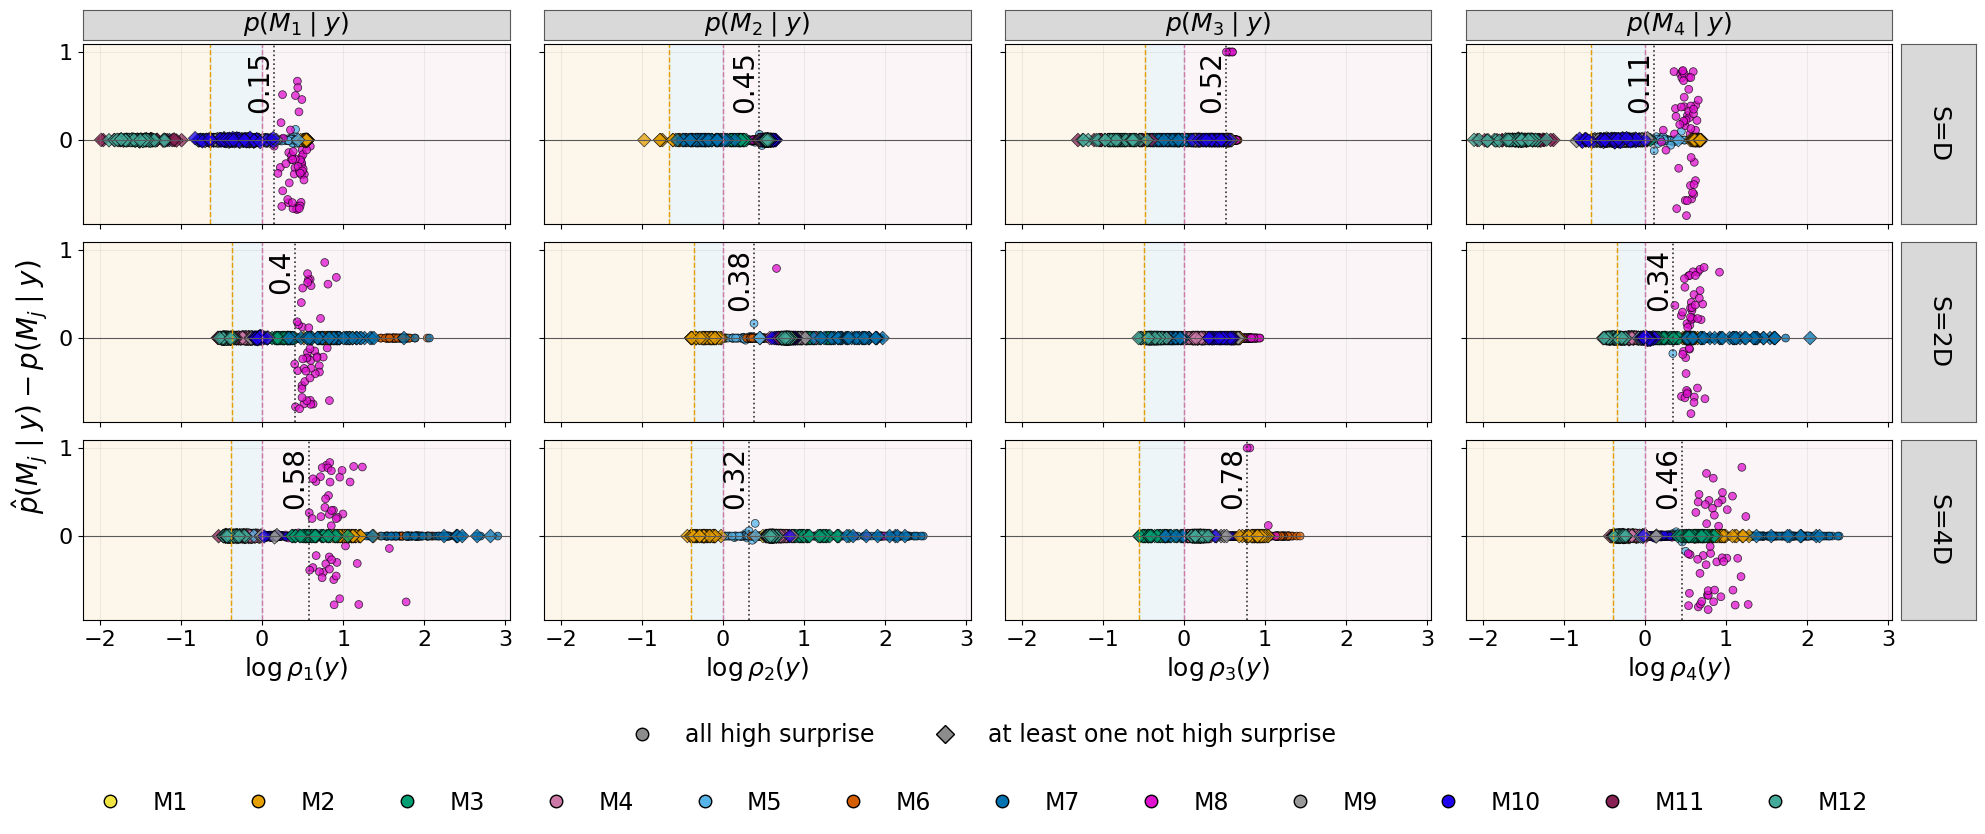

In [11]:
def plot_combined_logrho_signed_error(pmp_by_summary, error_bound=0.05):
    assumed_models = sd.ASSUMED_MODELS
    row_labels = list(pmp_by_summary)
    col_labels = [rf"$p(M_{model[1:]}\mid y)$" for model in assumed_models]
    x_min = -0.5
    x_max = 0.0
    for data in pmp_by_summary.values():
        for model in assumed_models:
            rho = data[f"d_{model}"] / data[f"dm_high_{model}"]
            log_rho = np.log(rho)
            x_min = min(x_min, float(log_rho.min()) * 1.05)
            x_max = max(x_max, float(log_rho.max()) * 1.05)

    fig, axes = plt.subplots(
        len(row_labels),
        len(assumed_models),
        figsize=(4.4 * len(assumed_models) + 3.2, 3.0 * len(row_labels)),
        sharex=True,
        sharey=True,
    )
    fig.subplots_adjust(left=0.07, right=0.94, bottom=0.24, top=0.88, wspace=0.08, hspace=0.10)

    for r, (row_label, data) in enumerate(pmp_by_summary.items()):
        for c, model in enumerate(assumed_models):
            ax = axes[r, c]
            rho = data[f"d_{model}"] / data[f"dm_high_{model}"]
            x = np.log(rho)
            y = data[f"signed_pmp_error_npe_{model}"]
            low = float(np.log((data[f"dm_low_{model}"] / data[f"dm_high_{model}"]).iloc[0]))

            add_distance_regions(ax, low=low, high=0.0, x_min=x_min, x_max=x_max)
            scatter_by_class_and_source(ax, data, x, y)
            add_first_large_error(ax, data, x, y, error_bound=error_bound)
            ax.axhline(0, color="0.35", linewidth=0.8)
            ax.set_xlim(x_min, x_max)

    xlabel_by_col = [rf"$\log \rho_{model[1:]}(y)$" for model in assumed_models]
    style_panel_grid(fig, axes, xlabel_by_col, r"$\hat{p}(M_j\mid y)-p(M_j\mid y)$", row_labels, col_labels)
    return fig, axes


fig_logrho, axes_logrho = plot_combined_logrho_signed_error(pmp_by_summary)


Removed rho outliers above the 99% quantile: rho > 7.840


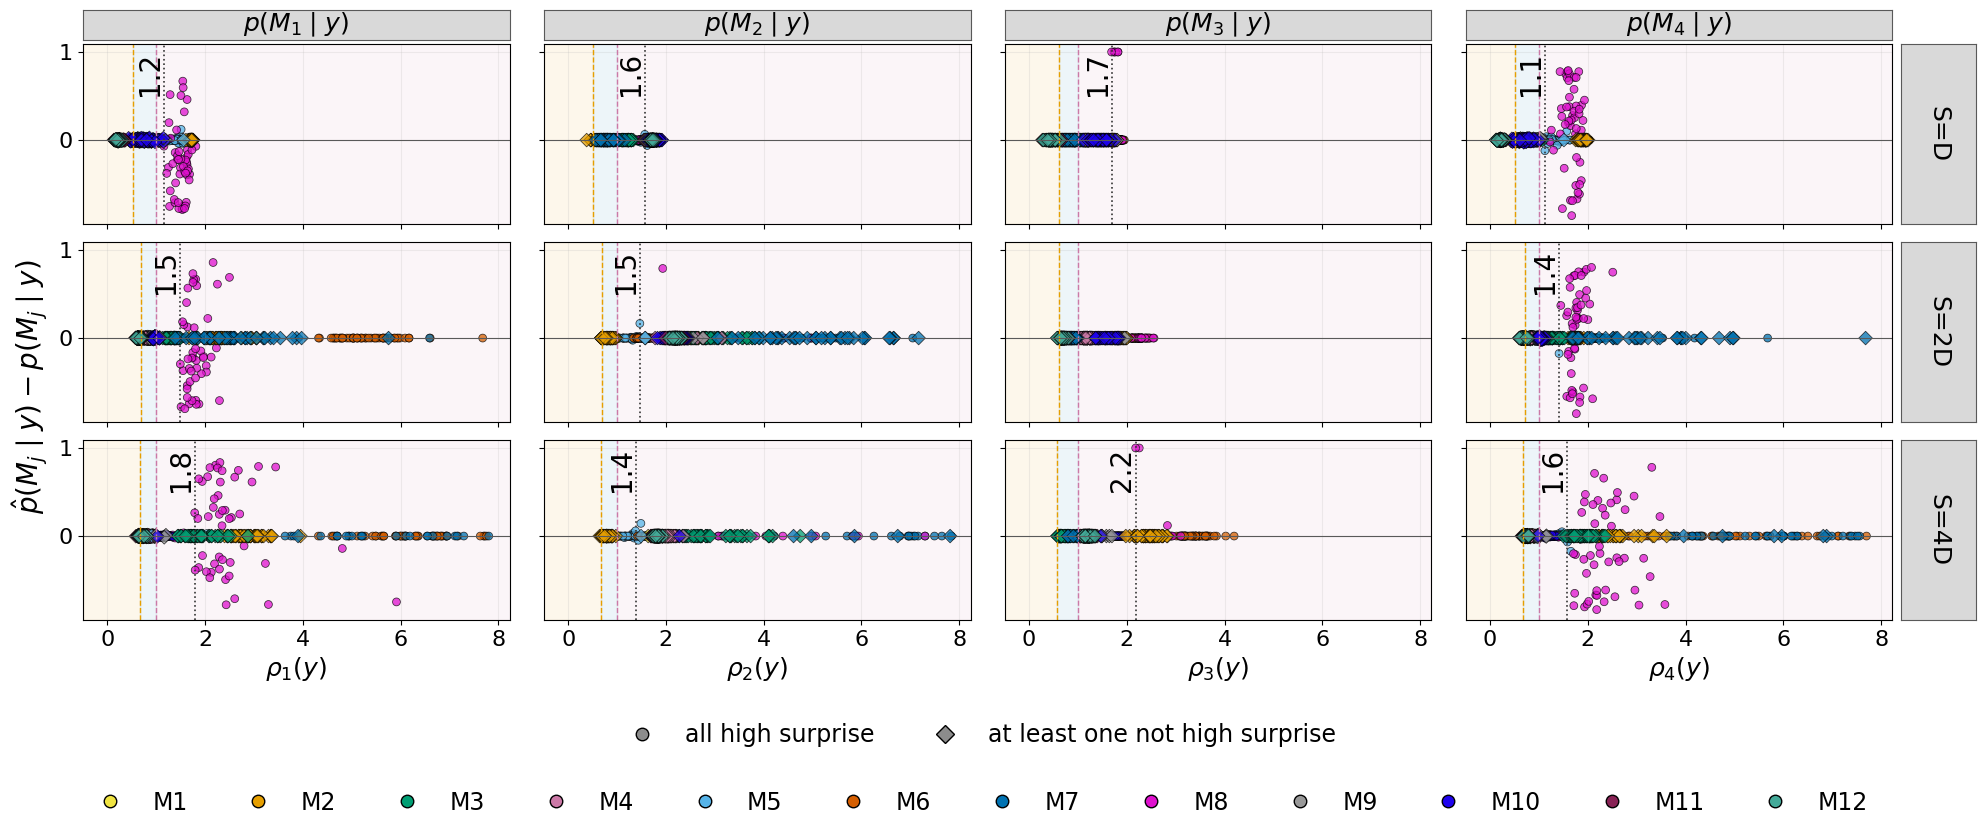

In [12]:
def plot_combined_rho_signed_error_without_outliers(pmp_by_summary, error_bound=0.05, upper_quantile=0.99):
    assumed_models = sd.ASSUMED_MODELS
    row_labels = list(pmp_by_summary)
    col_labels = [rf"$p(M_{model[1:]}\mid y)$" for model in assumed_models]
    x_min = -0.5

    all_rho = []
    for data in pmp_by_summary.values():
        for model in assumed_models:
            all_rho.append((data[f"d_{model}"] / data[f"dm_high_{model}"]).to_numpy())
    rho_cutoff = float(np.quantile(np.concatenate(all_rho), upper_quantile))
    x_max = rho_cutoff * 1.05

    fig, axes = plt.subplots(
        len(row_labels),
        len(assumed_models),
        figsize=(4.4 * len(assumed_models) + 3.2, 3.0 * len(row_labels)),
        sharex=True,
        sharey=True,
    )
    fig.subplots_adjust(left=0.07, right=0.94, bottom=0.24, top=0.88, wspace=0.08, hspace=0.10)

    for r, (row_label, data) in enumerate(pmp_by_summary.items()):
        for c, model in enumerate(assumed_models):
            ax = axes[r, c]
            rho = data[f"d_{model}"] / data[f"dm_high_{model}"]
            keep = rho <= rho_cutoff
            plot_data = data[keep]
            x = rho[keep]
            y = data.loc[keep, f"signed_pmp_error_npe_{model}"]
            low = float((data[f"dm_low_{model}"] / data[f"dm_high_{model}"]).iloc[0])

            add_distance_regions(ax, low=low, high=1.0, x_min=x_min, x_max=x_max)
            scatter_by_class_and_source(ax, plot_data, x, y)
            add_first_large_error(ax, plot_data, x, y, error_bound=error_bound)
            ax.axhline(0, color="0.35", linewidth=0.8)
            ax.set_xlim(x_min, x_max)

    xlabel_by_col = [rf"$\rho_{model[1:]}(y)$" for model in assumed_models]
    style_panel_grid(fig, axes, xlabel_by_col, r"$\hat{p}(M_j\mid y)-p(M_j\mid y)$", row_labels, col_labels)
    return fig, axes, rho_cutoff


fig_rho_trimmed, axes_rho_trimmed, rho_outlier_cutoff = plot_combined_rho_signed_error_without_outliers(pmp_by_summary)
print(f"Removed rho outliers above the {0.99:.0%} quantile: rho > {rho_outlier_cutoff:.3f}")


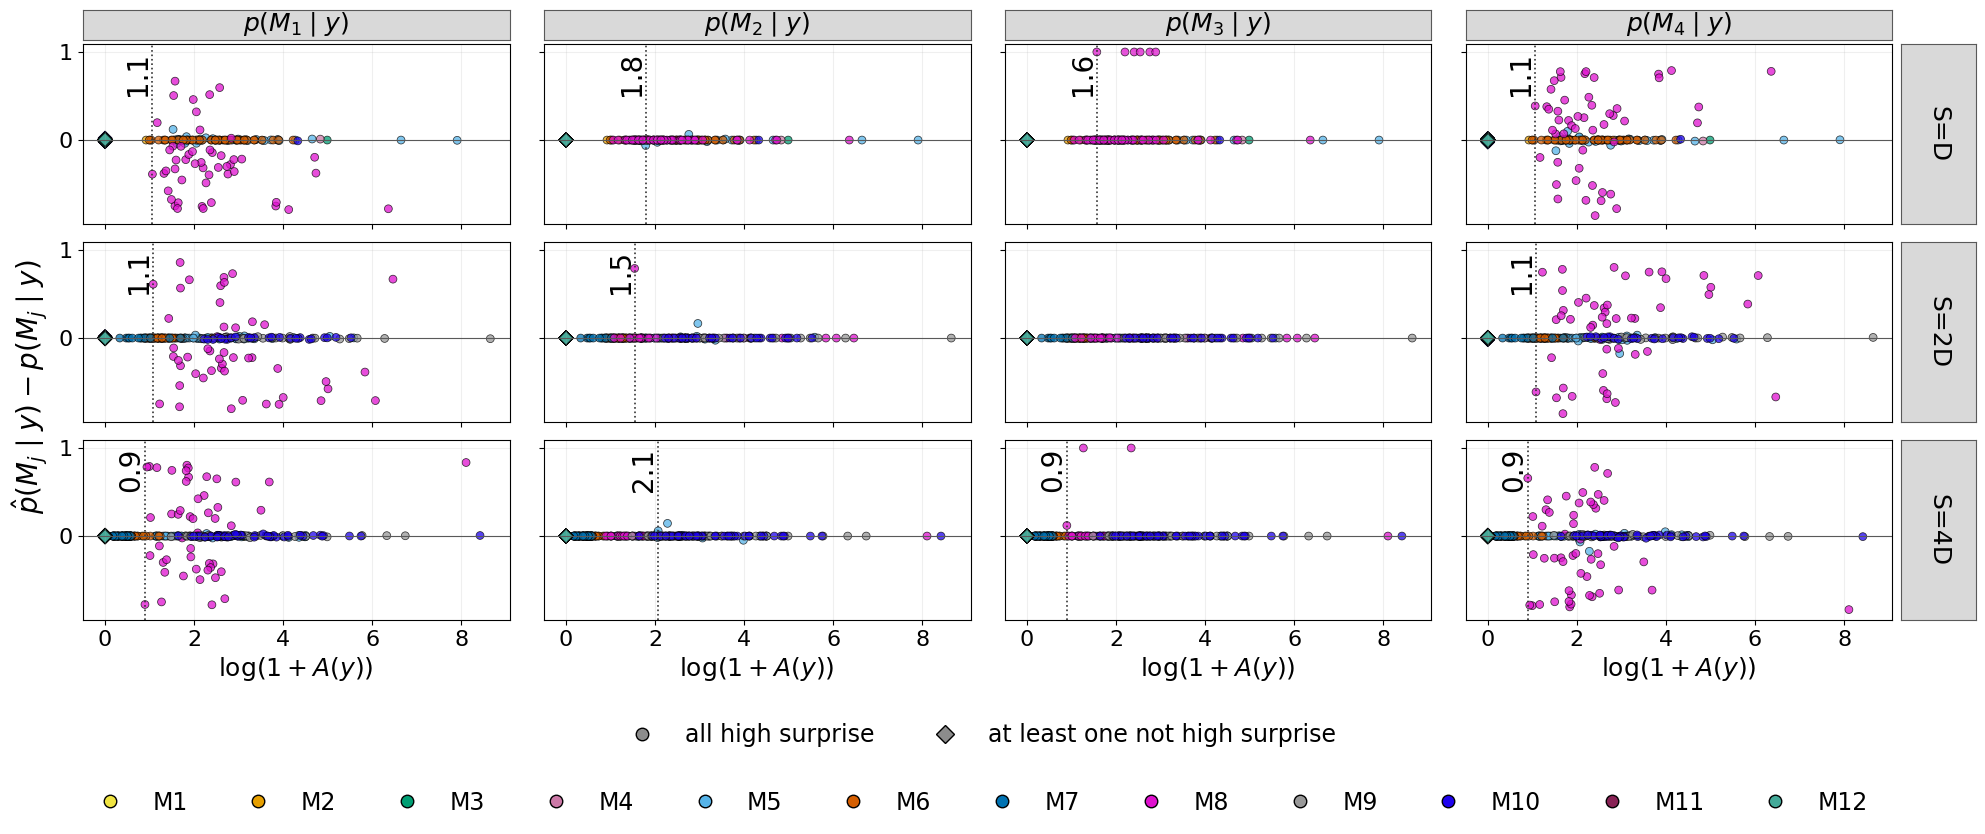

In [13]:
def plot_combined_logA_signed_error(pmp_by_summary, error_bound=0.05):
    assumed_models = sd.ASSUMED_MODELS
    row_labels = list(pmp_by_summary)
    col_labels = [rf"$p(M_{model[1:]}\mid y)$" for model in assumed_models]
    x_min = -0.5
    x_max = 0.0
    for data in pmp_by_summary.values():
        x_max = max(x_max, float(np.log1p(data["ambiguity_score"]).max()) * 1.05)

    fig, axes = plt.subplots(
        len(row_labels),
        len(assumed_models),
        figsize=(4.4 * len(assumed_models) + 3.2, 3.0 * len(row_labels)),
        sharex=True,
        sharey=True,
    )
    fig.subplots_adjust(left=0.07, right=0.94, bottom=0.24, top=0.88, wspace=0.08, hspace=0.10)

    for r, (row_label, data) in enumerate(pmp_by_summary.items()):
        x = np.log1p(data["ambiguity_score"])
        all_extrapolative = data[data["at_least_one_not_extrapolative"] == False]

        for c, model in enumerate(assumed_models):
            ax = axes[r, c]
            y = data[f"signed_pmp_error_npe_{model}"]
            scatter_by_class_and_source(ax, data, x, y)
            add_first_large_error(ax, all_extrapolative, x, y, error_bound=error_bound)
            ax.axhline(0, color="0.35", linewidth=0.8)
            ax.set_xlim(x_min, x_max)

    xlabel_by_col = [r"$\log(1+A(y))$"] * len(assumed_models)
    style_panel_grid(fig, axes, xlabel_by_col, r"$\hat{p}(M_j\mid y)-p(M_j\mid y)$", row_labels, col_labels)
    return fig, axes


fig_logA, axes_logA = plot_combined_logA_signed_error(pmp_by_summary)


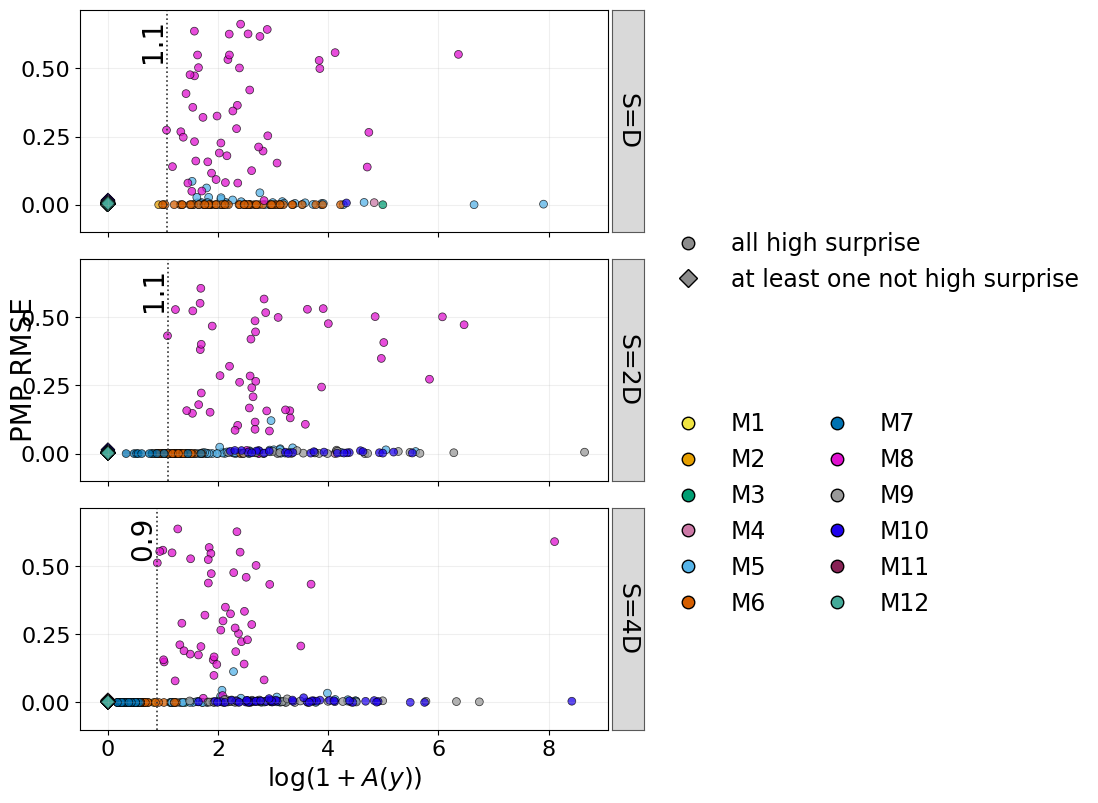

In [14]:
def pmp_rmse(data, estimate="npe"):
    error_cols = [f"signed_pmp_error_{estimate}_{model}" for model in sd.ASSUMED_MODELS]
    return np.sqrt(np.mean(np.square(data[error_cols].to_numpy(float)), axis=1))


def plot_combined_logA_rmse(pmp_by_summary, error_bound=0.05):
    row_labels = list(pmp_by_summary)
    x_min = -0.5
    x_max = 0.0
    y_min = -0.1
    y_max = 1e-12
    for data in pmp_by_summary.values():
        x_max = max(x_max, float(np.log1p(data["ambiguity_score"]).max()) * 1.05)
        y_max = max(y_max, float(pmp_rmse(data).max()) * 1.08)

    fig, axes = plt.subplots(
        len(row_labels),
        1,
        figsize=(8.8, 3.0 * len(row_labels)),
        sharex=True,
        sharey=True,
    )
    axes = np.atleast_1d(axes)
    axes_2d = axes.reshape(-1, 1)
    fig.subplots_adjust(left=0.12, right=0.72, bottom=0.10, top=0.90, hspace=0.12)

    for ax, (row_label, data) in zip(axes, pmp_by_summary.items(), strict=False):
        x = np.log1p(data["ambiguity_score"])
        y = pd.Series(pmp_rmse(data), index=data.index)
        scatter_by_class_and_source(ax, data, x, y)
        add_first_large_error(ax, data, x, y, error_bound=error_bound)
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.grid(alpha=0.2)
        ax.tick_params(labelsize=16)

    axes[-1].set_xlabel(r"$\log(1+A(y))$", fontsize=18)
    fig.supylabel("PMP RMSE", x=0.04, fontsize=20)
    add_facet_strips(fig, axes_2d, row_labels=row_labels)
    add_right_legend(fig, x=0.76)
    return fig, axes


fig_rmse, axes_rmse = plot_combined_logA_rmse(pmp_by_summary)
